In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("assignment3_transformer_gnn_compression.ipynb")

In [2]:
import copy
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils import prune

%matplotlib inline

np.random.seed(42)
_ = torch.manual_seed(42)

def rel_error(x, y):
    return torch.max(torch.abs(x - y) / torch.clamp(torch.abs(x) + torch.abs(y), min=1e-8)).item()


def generate_synthetic_sequence_data(n_samples=320, seq_len=12, vocab_size=40, seed=42):
    g = torch.Generator().manual_seed(seed)
    X = torch.randint(low=0, high=vocab_size, size=(n_samples, seq_len), generator=g)

    high_half = (X[:, : seq_len // 2] > (vocab_size // 2)).float().mean(dim=1)
    parity_signal = (X[:, -1] % 2 == 0).float() * 0.15
    score = high_half + parity_signal
    y = (score > 0.6).long()
    return X, y


class CompressionProbeNet(nn.Module):
    def __init__(self, vocab_size=40, embed_dim=16, hidden_dim=32, num_classes=2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        h = self.embed(x).mean(dim=1)
        h = self.act(self.fc1(h))
        return self.fc2(h)


def train_probe_model(model, X_train, y_train, epochs=12, lr=3e-3, batch_size=64):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    n = X_train.shape[0]
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i : i + batch_size]
            xb, yb = X_train[idx], y_train[idx]
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
    return model


def evaluate_accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        preds = torch.argmax(logits, dim=1)
        return (preds == y).float().mean().item()


print("A3 environment initialized.")

A3 environment initialized.


# Assignment 3: Transformers, Graph Learning, and Pruning-Based Compression

**Total Points: 100**

This assignment focuses on three modern deep learning directions:
1. Transformer core mechanics.
2. A lightweight graph neural network (GNN) message-passing layer.
3. Practical compression techniques using multiple pruning criteria.

You will implement core components with an emphasis on both correctness and robustness.
All tasks are designed to run on CPU with synthetic/toy data only.

## Notebook Roadmap and Math Notation

### Roadmap
1. **Q1**: implement scaled dot-product attention.
2. **Q2**: implement multi-head self-attention primitives.
3. **Q3**: assemble a Transformer encoder block.
4. **Q4**: implement a compact GCN-style message passing layer.
5. **Q5**: apply and compare multiple pruning criteria.

### Tensor Notation
- `B`: batch size
- `L`: sequence length
- `H`: number of attention heads
- `Dk`, `Dv`: key/value dimensions per head
- `D_model`: model feature width
- `N`: number of graph nodes

### Reading Guide
Each question follows a uniform structure:
`Concept -> Math -> Input/Output Contract -> Implementation Requirements -> Common Pitfalls -> Complexity Hint`

## Question 1 (20 pts): Scaled Dot-Product Attention

### Concept
Attention maps each query token to a weighted mixture of value tokens, where weights are based on query-key similarity.

### Math
$$
	\text{Attention}(Q,K,V) = 	ext{softmax}\left(\frac{QK^T}{\sqrt{d_k}} + M\right)V
$$
where masked entries in \(M\) behave like \(-\infty\).

### Input/Output Contract
- Input `Q`, `K`: `(B, H, L, Dk)`
- Input `V`: `(B, H, L, Dv)`
- Optional `mask`: broadcastable to `(B, H, L, L)`, with `1` meaning keep and `0` meaning masked.
- Return `(output, attn_weights)` with shapes `(B, H, L, Dv)` and `(B, H, L, L)`.

### Implementation Requirements
- Scale logits by `sqrt(Dk)`.
- Apply mask before softmax.
- Use numerically stable tensor operations (no Python loops over tokens).

### Common Pitfalls
- Forgetting to transpose the last two dims of `K`.
- Applying mask after softmax.
- Returning wrong attention shape.

### Complexity Hint
Time complexity is roughly \(O(B \cdot H \cdot L^2 \cdot Dk)\).

In [3]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    # Q: (B, H, Lq, Dk), K: (B, H, Lk, Dk), V: (B, H, Lk, Dv)
    # mask: broadcastable to (B, H, Lq, Lk), where 1=keep and 0=mask
    # returns (output, attn_weights)
    d_k = K.size(-1)
    # 计算缩放点积: (B, H, Lq, Dk) @ (B, H, Dk, Lk) -> (B, H, Lq, Lk)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # 应用 Mask (如果提供)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    # 计算 Softmax 得到注意力权重
    attn_weights = torch.softmax(scores, dim=-1)

    # 对 V 加权求和: (B, H, Lq, Lk) @ (B, H, Lk, Dv) -> (B, H, Lq, Dv)
    output = torch.matmul(attn_weights, V)

    return output, attn_weights

In [4]:
grader.check("q1_scaled_dot_attention")

q1_scaled_dot_attention results: All test cases passed!

## Question 2 (20 pts): Multi-Head Self-Attention Core

### Concept
Multi-head attention lets the model attend to different relational patterns in parallel subspaces.

### Math
Split model dimension: $D_{model} = H 	\times D_{head}$. For each head:
$$
	{head}_i = 	{Attention}(Q_i, K_i, V_i)
$$
Then concatenate all heads and project back to `D_model`.

### Input/Output Contract
- `split_heads(x, num_heads)`: `(B, L, D_model) -> (B, H, L, D_head)`
- `combine_heads(x)`: `(B, H, L, D_head) -> (B, L, D_model)`
- `MiniMultiHeadSelfAttention.forward(x, mask=None)`: `(B, L, D_model) -> (B, L, D_model)`

### Implementation Requirements
- Enforce divisibility of `D_model` by `num_heads`.
- Use `scaled_dot_product_attention` from Q1.
- Keep operations fully batched.

### Common Pitfalls
- Wrong reshape order when splitting/combining heads.
- Forgetting to call `.contiguous()` before `view` after transpose.
- Hard-coding dimensions.

### Complexity Hint
Attention dominates with $O(L^2)$ behavior per head.

In [5]:
def split_heads(x, num_heads):
    # Input: x of shape (B, L, D_model)
    # Output: shape (B, num_heads, L, D_head)
    B, L, D_model = x.size()
    # 计算每个头的维度
    d_head = D_model // num_heads

    # 1. view: 拆分最后的维度 -> (B, L, num_heads, d_head)
    # 2. transpose: 交换序列长度 L 和头数 num_heads 的位置 -> (B, num_heads, L, d_head)
    return x.view(B, L, num_heads, d_head).transpose(1, 2)

def combine_heads(x):
    # Input: x of shape (B, num_heads, L, D_head)
    # Output: shape (B, L, D_model)
    B, num_heads, L, d_head = x.size()
    D_model = num_heads * d_head

    # 1. transpose: 把头数和序列长度换回来 -> (B, L, num_heads, d_head)
    # 2. contiguous: 确保内存连续（转置后必须做这一步才能用 view）
    # 3. view: 合并最后两个维度 -> (B, L, D_model)
    return x.transpose(1, 2).contiguous().view(B, L, D_model)

class MiniMultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        # 强制检查整除关系
        if d_model % num_heads != 0:
            raise ValueError(f"d_model ({d_model}) must be divisible by num_heads ({num_heads})")
        self.num_heads = num_heads

        # 定义生成 Q, K, V 的线性投影层
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)

        # 定义输出的线性投影层
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)


    def forward(self, x, mask=None):
        # 1. 线性投影获取 Q, K, V
        Q = self.q_proj(x)
        K = self.k_proj(x)
        V = self.v_proj(x)
        # 2. 拆分成多头
        Q = split_heads(Q, self.num_heads)
        K = split_heads(K, self.num_heads)
        V = split_heads(V, self.num_heads)

        # 3. 传入 Q1 写好的注意力函数 (带上 mask)
        attn_output, _ = scaled_dot_product_attention(Q, K, V, mask=mask)

        # 4. 合并多头
        combined_output = combine_heads(attn_output)

        # 5. 最终输出投影与 Dropout
        out = self.dropout(self.out_proj(combined_output))
        return out

In [6]:
grader.check("q2_multihead_attention_core")

q2_multihead_attention_core results: All test cases passed!

## Question 3 (20 pts): Transformer Encoder Block

### Concept
An encoder block combines self-attention (token interaction) and a feed-forward network (feature transformation), each wrapped by residual connection + normalization.

### Math
$$
X' = 	{LayerNorm}(X + 	{SelfAttention}(X))
$$
$$
Y = 	{LayerNorm}(X' + 	{FFN}(X'))
$$

### Input/Output Contract
- Constructor args: `d_model`, `num_heads`, `ff_hidden_dim`, `dropout`
- `forward(x, mask=None)` with input/output shape `(B, L, d_model)`

### Implementation Requirements
- Include residual path around both attention and FFN.
- Include two LayerNorm modules.
- FFN must map `d_model -> ff_hidden_dim -> d_model`.

### Common Pitfalls
- Applying LayerNorm to the wrong tensor.
- Omitting one residual connection.
- Creating FFN as identity by mistake.

### Complexity Hint
One block has attention cost $O(L^2 d)$ and FFN cost $O(L d \cdot d_{ff})$.

In [7]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_hidden_dim, dropout=0.1):
        super().__init__()
        # === 1. 第一个子层：多头自注意力机制 ===
        # 调用 Q2 写好的类
        self.attention = MiniMultiHeadSelfAttention(d_model, num_heads, dropout=dropout)
        # 为第一个子层定义 LayerNorm
        self.norm1 = nn.LayerNorm(d_model)


        # === 2. 第二个子层：前馈神经网络 (FFN) ===
        # 维度映射：d_model -> ff_hidden_dim -> d_model
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_hidden_dim, d_model)
        )

        # 为第二个子层定义 LayerNorm
        self.norm2 = nn.LayerNorm(d_model)

        # Dropout 层，用于残差连接相加之前（可选，增强泛化能力）
        self.dropout = nn.Dropout(dropout)


    def forward(self, x, mask=None):
        # 子层 1：Attention + 残差 + LayerNorm
        attn_output = self.attention(x, mask=mask)
        # 加入 dropout 后与原输入 x 相加，然后归一化
        x = self.norm1(x + self.dropout(attn_output))

        # 子层 2：FFN + 残差 + LayerNorm
        ffn_output = self.ffn(x)
        # 加入 dropout 后与上一步的输出 x 相加，然后归一化
        out = self.norm2(x + self.dropout(ffn_output))

        return out

In [8]:
grader.check("q3_transformer_encoder_block")

q3_transformer_encoder_block results: All test cases passed!

## Question 4 (15 pts): Lightweight GNN Layer (GCN-style)

### Concept
A GNN aggregates neighbor information over a graph. In GCN, normalized adjacency controls message scaling.

### Math
With self-loops added:
$$
\hat{A} = A + I, \quad \hat{D}_{ii} = \sum_j \hat{A}_{ij}
$$
$$
X' = \hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2} X W + b
$$

### Input/Output Contract
- `X`: node features `(N, Fin)`
- `A`: adjacency matrix `(N, N)`
- Output: `(N, Fout)`

### Implementation Requirements
- Add self-loops internally.
- Use symmetric normalization.
- Ensure stable behavior for sparse graphs and isolated nodes.

### Common Pitfalls
- Forgetting self-loops.
- Degree inverse with divide-by-zero.
- Mixing up matrix multiplication order.

### Complexity Hint
Dense implementation costs roughly $O(N^2 F_{in} + N F_{in} F_{out})$.

In [9]:
class SimpleGCNLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # 定义权重参数 W: 形状为 (out_features, in_features) 方便做线性变换
        self.weight = nn.Parameter(torch.empty(out_features, in_features))

        # 定义偏置参数 b
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.register_parameter('bias', None)

        # 初始化权重
        self.reset_parameters()


    def reset_parameters(self):
        # 使用 Kaiming 均匀分布初始化
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            nn.init.uniform_(self.bias, -bound, bound)


    def forward(self, X, A):
        # X: node features, shape (N, Fin)
        # A: adjacency matrix without self-loops, shape (N, N)
        N = A.size(0)
        I = torch.eye(N, device=A.device)

        # 1. 添加自环 (Self-loops): A_hat = A + I
        I = torch.eye(N, dtype=A.dtype, device=A.device)
        A_hat = A + I

        # 2. 计算度矩阵 D_hat 及其 -1/2 次方
        # 对行求和得到度
        degree = A_hat.sum(dim=1)
        # 因为加了自环，degree 最小为 1，不会出现除以 0 的情况，直接算 -1/2 次方是安全的
        d_inv_sqrt = torch.pow(degree, -0.5)

        # 构造对角矩阵 D^{-1/2}
        D_inv_sqrt = torch.diag(d_inv_sqrt)

        # 3. 计算归一化的邻接矩阵: A_norm = D^{-1/2} * A_hat * D^{-1/2}
        A_norm = torch.matmul(D_inv_sqrt, torch.matmul(A_hat, D_inv_sqrt))

        # 4. 图卷积前向传播: X' = A_norm * X * W + b
        # 先做线性变换 X * W  (注意 weight 是 out x in，所以这里要转置)
        support = torch.matmul(X, self.weight.t())

        # 然后沿着图结构进行信息聚合
        out = torch.matmul(A_norm, support)

        # 最后加上偏置
        if self.bias is not None:
            out = out + self.bias
            
        return out

In [10]:
grader.check("q4_simple_gnn_layer")

q4_simple_gnn_layer results: All test cases passed!

## Question 5 (25 pts): Pruning Utilities with Multiple Criteria

### Concept
Pruning reduces effective model complexity by setting selected weights (or channels) to zero while keeping tensor shapes unchanged.
In this question, you will compare **three pruning criteria** on linear layers.

### Math
- **Global L1 pruning**: remove smallest-absolute weights globally across all prunable layers.
- **Global random pruning**: remove randomly selected weights globally with the same target sparsity.
- **Structured \(L_n\) pruning**: remove full output channels according to channel norms.
- **Sparsity**: $1 - \frac{\#	\text{nonzero}}{\#	\text{total}}$.

### Input/Output Contract
Implement:
1. `apply_global_pruning(model, sparsity=0.5, criterion="l1")`
2. `model_stats(model)` returning keys `{total_params, nonzero_params, sparsity}`

Supported criteria:
- `"l1"`
- `"random"`
- `"ln_structured"`

### Implementation Requirements
- Pruning must target `nn.Linear.weight` tensors.
- `"l1"` and `"random"` should perform global unstructured pruning.
- `"ln_structured"` should prune full output channels in linear layers.
- Raise a clear `ValueError` for unsupported criterion names.
- Statistics must reflect current parameter state.

### Common Pitfalls
- Ignoring the `criterion` argument and always using one method.
- Forgetting to materialize pruned weights (masks only).
- Confusing unstructured pruning with structured channel pruning.

### Complexity Hint
Pruning setup is usually cheap relative to training; behavior differences mainly come from which parameters/channels are removed.

In [11]:
def apply_global_pruning(model, sparsity=0.5, criterion="l1"):
    # 1. 收集所有目标层：只针对 nn.Linear 层，且只剪裁 'weight' 参数
    parameters_to_prune = []
    linear_modules = []
    
    for module in model.modules():
        if isinstance(module, nn.Linear):
            parameters_to_prune.append((module, 'weight'))
            linear_modules.append(module)
            
    # 2. 根据 criterion 应用不同的剪枝策略
    if criterion == "l1":
        # 全局 L1 剪枝：把所有线性层的权重放在一起比较，剪掉绝对值最小的
        prune.global_unstructured(
            parameters_to_prune,
            pruning_method=prune.L1Unstructured,
            amount=sparsity,
        )
    elif criterion == "random":
        # 全局随机剪枝
        prune.global_unstructured(
            parameters_to_prune,
            pruning_method=prune.RandomUnstructured,
            amount=sparsity,
        )
    elif criterion == "ln_structured":
        # 结构化 Ln 剪枝：PyTorch 的 global_unstructured 不支持结构化
        # 因此我们需要循环遍历每个线性层，按照 dim=0 (输出通道) 剪掉一整行
        for module in linear_modules:
            prune.ln_structured(
                module, 
                name="weight", 
                amount=sparsity, 
                n=2,       # 使用 L2 范数来衡量通道的重要性
                dim=0      # dim=0 代表去除完整的输出通道 (Output Channels)
            )
    else:
        # 如果传入了不支持的 criterion，抛出异常
        raise ValueError(f"Unsupported criterion: {criterion}")
        
    # 3. 固化剪枝 (Materialize)
    # PyTorch 默认会保留原始权重 ('weight_orig') 和掩码 ('weight_mask')
    # prune.remove 会把掩码永久应用到权重上，并将参数恢复为纯粹的 'weight'
    for module in linear_modules:
        prune.remove(module, 'weight')


def model_stats(model):
    # Return parameter statistics as a dictionary.
    total_params = 0
    nonzero_params = 0
    
    # 遍历模型中的所有参数（不仅是线性层，也包括 Embedding, Bias 等）
    for param in model.parameters():
        total_params += param.numel()
        # 计算不为 0 的参数个数
        nonzero_params += (param != 0).sum().item()
        
    # 计算稀疏度： 1 - (非零参数 / 总参数)
    sparsity = 1.0 - (nonzero_params / total_params) if total_params > 0 else 0.0
    
    return {
        "total_params": total_params,
        "nonzero_params": nonzero_params,
        "sparsity": sparsity
    }

In [12]:
grader.check("q5_pruning_criteria")

q5_pruning_criteria results: All test cases passed!

## Optional Demo: Compare Pruning Criteria on a Tiny Sequence Classifier

Base accuracy:       0.641 | stats: {'total_params': 1250, 'nonzero_params': 1250, 'sparsity': 0.0}
L1-pruned accuracy:  0.672 | stats: {'total_params': 1250, 'nonzero_params': 962, 'sparsity': 0.23040000000000005}
Random-pruned acc:   0.672 | stats: {'total_params': 1250, 'nonzero_params': 962, 'sparsity': 0.23040000000000005}
Structured-pruned:   0.656 | stats: {'total_params': 1250, 'nonzero_params': 962, 'sparsity': 0.23040000000000005}


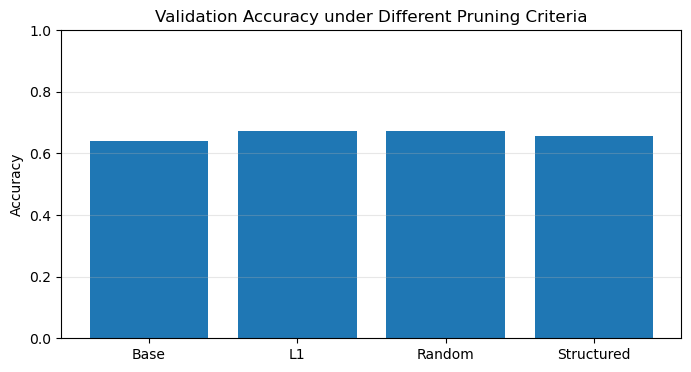

In [13]:
X, y = generate_synthetic_sequence_data(n_samples=320, seq_len=12, vocab_size=40, seed=42)
X_train, y_train = X[:256], y[:256]
X_val, y_val = X[256:], y[256:]

model = CompressionProbeNet(vocab_size=40, embed_dim=16, hidden_dim=32, num_classes=2)
_ = train_probe_model(model, X_train, y_train, epochs=12, lr=3e-3, batch_size=64)
base_acc = evaluate_accuracy(model, X_val, y_val)
base_stats = model_stats(model)

pruned_l1 = copy.deepcopy(model)
_ = apply_global_pruning(pruned_l1, sparsity=0.5, criterion="l1")
acc_l1 = evaluate_accuracy(pruned_l1, X_val, y_val)
stats_l1 = model_stats(pruned_l1)

pruned_random = copy.deepcopy(model)
_ = apply_global_pruning(pruned_random, sparsity=0.5, criterion="random")
acc_random = evaluate_accuracy(pruned_random, X_val, y_val)
stats_random = model_stats(pruned_random)

pruned_struct = copy.deepcopy(model)
_ = apply_global_pruning(pruned_struct, sparsity=0.5, criterion="ln_structured")
acc_struct = evaluate_accuracy(pruned_struct, X_val, y_val)
stats_struct = model_stats(pruned_struct)

print(f"Base accuracy:       {base_acc:.3f} | stats: {base_stats}")
print(f"L1-pruned accuracy:  {acc_l1:.3f} | stats: {stats_l1}")
print(f"Random-pruned acc:   {acc_random:.3f} | stats: {stats_random}")
print(f"Structured-pruned:   {acc_struct:.3f} | stats: {stats_struct}")

plt.figure(figsize=(8, 4))
plt.bar(
    ["Base", "L1", "Random", "Structured"],
    [base_acc, acc_l1, acc_random, acc_struct]
)
plt.ylim(0.0, 1.0)
plt.title("Validation Accuracy under Different Pruning Criteria")
plt.ylabel("Accuracy")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [15]:
# Save your notebook first, then run this cell to export your submission.
# grader.export(run_tests=True)